<a href="https://colab.research.google.com/github/20KaRaKuM20/NM/blob/main/%D0%BB%D1%803_2_%D0%92%D0%B8%D1%81%D0%BE%D1%86%D1%8C%D0%BA%D0%B8%D0%B9_%D0%92%D0%BE%D0%BB%D0%BE%D0%B4%D0%B8%D0%BC%D0%B8%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завдання 3. Лабораторна робота 3

Тема: Відокремлення дійсних коренів рівнянь та їх уточнення методом простої ітерації.

In [ ]:
!pip install numdifftools

In [ ]:
import numdifftools as nd

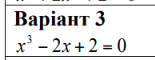

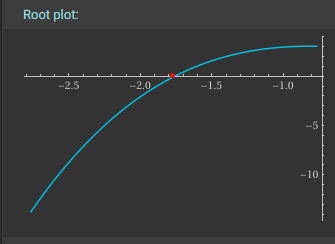

Визначаємо, що корінь належить відрізку [-2,-1]

In [ ]:
def f(x: float):
    return x**3 - 2*x + 2

def fprime(x: float):
    return nd.Derivative(f, n=1)

def phi(x: float):
    # c = -0.1 (забезпечує |phi'(x)|<1 на [-2,-1])
    c = -0.1
    return x + c * f(x)

def iterate_fixed_point(x0: float, iters: int = 5):
    xs = [x0]
    x = x0
    for _ in range(iters):
        x = phi(x)
        xs.append(x)
    return xs

def error_bound(x_last: float) -> float:
    # μ = min_{x∈[-2,-1]} |f'(x)| = 2
    mu = 2.0
    return abs(f(x_last)) / mu

In [ ]:
def main():
    x0 = -1.0 # нульове наближення має належати відрізку [-2, -1]

    iters = 5
    xs = iterate_fixed_point(x0, iters)

    print("Fixed-point iteration for f(x) = x^3 - 2x + 2 = 0 with phi(x) = x - 0.1*f(x)")
    print(f"Interval: [-2, -1], start x0 = {x0}")

    for i, xi in enumerate(xs):
        if i == 0:
            print(f"x_{i} = {xi:.10f}")
        else:
            print(f"x_{i} = phi(x_{i-1}) = {xi:.10f}")
    bound = error_bound(xs[-1])
    print("\nError bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ")
    print(f"f(x5) = {f(xs[-1]):.10f},  μ = 2  ⇒  |ξ - x5| ≤ {bound:.10f}")
    return xs[-1], bound

if __name__ == "__main__":
    root_approx, bound = main()

Fixed-point iteration for f(x) = x^3 - 2x + 2 = 0 with phi(x) = x - 0.1*f(x)
Interval: [-2, -1], start x0 = -1.0
x_0 = -1.0000000000
x_1 = phi(x_0) = -1.3000000000
x_2 = phi(x_1) = -1.5403000000
x_3 = phi(x_2) = -1.6829201144
x_4 = phi(x_3) = -1.7428641179
x_5 = phi(x_4) = -1.7620288361

Error bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ
f(x5) = 0.0534063626,  μ = 2  ⇒  |ξ - x5| ≤ 0.0267031813


Спрощений варіант коду




In [ ]:
# Рівняння: f(x) = x^3 - 2x + 2 = 0
# Ітераційна функція: φ(x) = x - 0.1 * f(x)  (c = -0.1)
# Початкове наближення: x0 = -1
# Кількість ітерацій: 5
# Оцінка похибки: |ξ - x5| ≤ |f(x5)| / μ, де μ = min_{[-2,-1]} |f'(x)| = 2

def f(x):
    return x**3 - 2*x + 2

def phi(x):
    return x - 0.1 * f(x)   # c = -0.1

def fixed_point(x0=-1.0, iters=5):
    xs = [x0]
    for _ in range(iters):
        xs.append(phi(xs[-1]))
    return xs

# Запуск і вивід результатів
xs = fixed_point(-1.0, 5)

for i, xi in enumerate(xs):
    print(f"x_{i} = {xi:.10f}")

# Похибка методу простої ітерації після 5-ї ітерації
mu = 2.0                      # μ = min_{[-3,-1]} |3x^2 - 1| = 2
err_bound = abs(f(xs[-1]))/mu
print(f"\nОцінка похибки: |ξ - x5| ≤ {err_bound:.10f}")

x_0 = -1.0000000000
x_1 = -1.3000000000
x_2 = -1.5403000000
x_3 = -1.6829201144
x_4 = -1.7428641179
x_5 = -1.7620288361

Оцінка похибки: |ξ - x5| ≤ 0.0267031813


Перевірка

In [ ]:
import sympy as sym

a, b = -2, -1

x, a, b = sym.symbols('x, a, b')
f = x**3 - 2*x + 2

s = sym.solve(f, x)
print(sym.nroots(f))

[-1.76929235423863, 0.884646177119316 - 0.589742805022206*I, 0.884646177119316 + 0.589742805022206*I]
